**Что такое файл Parquet?**

Файл Apache Parquet - это формат колоночного хранения данных, доступный любому проекту в экосистеме Hadoop, независимо от выбора фреймворка обработки данных, модели данных или языка программирования.

---
Преимущества:

При запросе к столбцовому хранилищу оно очень быстро пропускает нерелевантные данные, что ускоряет выполнение запроса. В результате запросы на агрегирование занимают меньше времени по сравнению с базами данных, ориентированными на строки.

Он способен поддерживать расширенные вложенные структуры данных.

Parquet поддерживает эффективные варианты сжатия и схемы кодирования.

Pyspark SQL поддерживает чтение и запись файлов Parquet, которые автоматически захватывают схему исходных данных, а также сокращают хранение данных в среднем на 75 %. Pyspark по умолчанию поддерживает Parquet в своей библиотеке, поэтому нам не нужно добавлять никаких зависимых библиотек.

In [7]:
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType,StructField,StringType,IntegerType,DoubleType

spark = (SparkSession.builder
         .appName("check-python")
         .master("local[*]")
         .config("spark.pyspark.python", sys.executable)
         .config("spark.pyspark.driver.python", sys.executable)
         .getOrCreate())

26/03/03 14:45:34 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [8]:
# Create Sample data

data =[("James ","","Smith","36636","M",3000),
              ("Michael ","Rose","","40288","M",4000),
              ("Robert ","","Williams","42114","M",4000),
              ("Maria ","Anne","Jones","39192","F",4000),
              ("Jen","Mary","Brown","","F",-1)]
columns=["firstname","middlename","lastname","dob","gender","salary"]
df=spark.createDataFrame(data,columns)

---
**Запись DataFrame в формат файла Parquet**


In [ ]:
# Write DataFrame to parquet file using write.parquet()
# Change path
df.write.parquet("people.parquet")

--- 
**Чтение паркетного файла**

Pyspark предоставляет метод parquet() в классе DataFrameReader для чтения паркетного файла в кадр данных (датафрейм). Ниже приведен пример чтения паркетного файла в кадр данных.

In [10]:
# Read parquet file using read.parquet()
parDF=spark.read.parquet("people.parquet")
parDF.show(truncate=False)

+---------+----------+--------+-----+------+------+
|firstname|middlename|lastname|dob  |gender|salary|
+---------+----------+--------+-----+------+------+
|Robert   |          |Williams|42114|M     |4000  |
|Maria    |Anne      |Jones   |39192|F     |4000  |
|Michael  |Rose      |        |40288|M     |4000  |
|James    |          |Smith   |36636|M     |3000  |
|Jen      |Mary      |Brown   |     |F     |-1    |
+---------+----------+--------+-----+------+------+



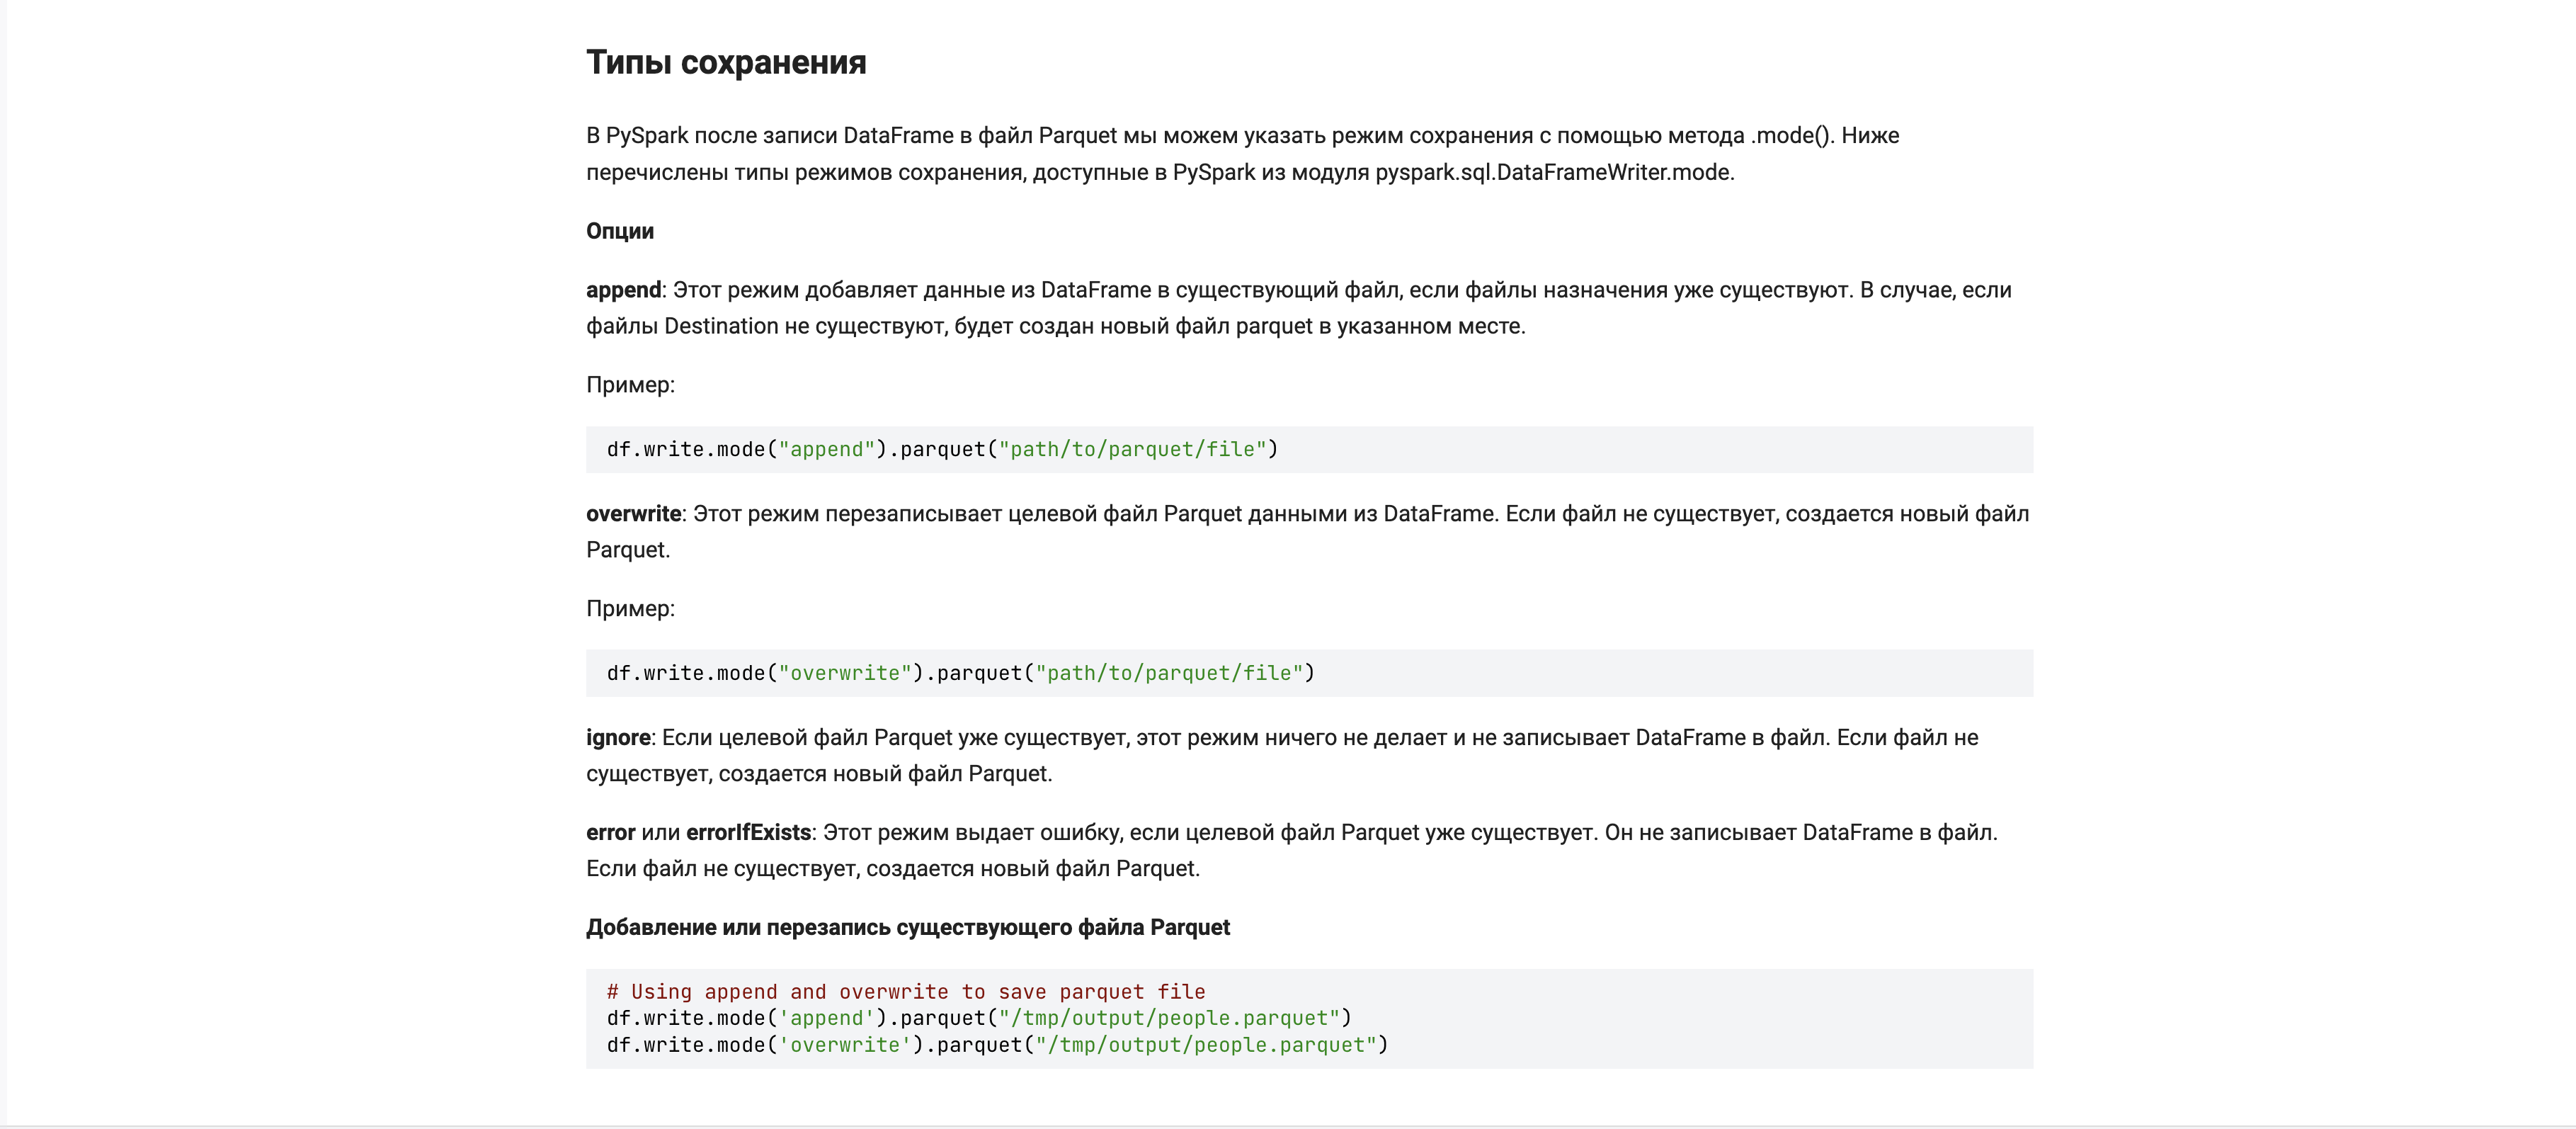
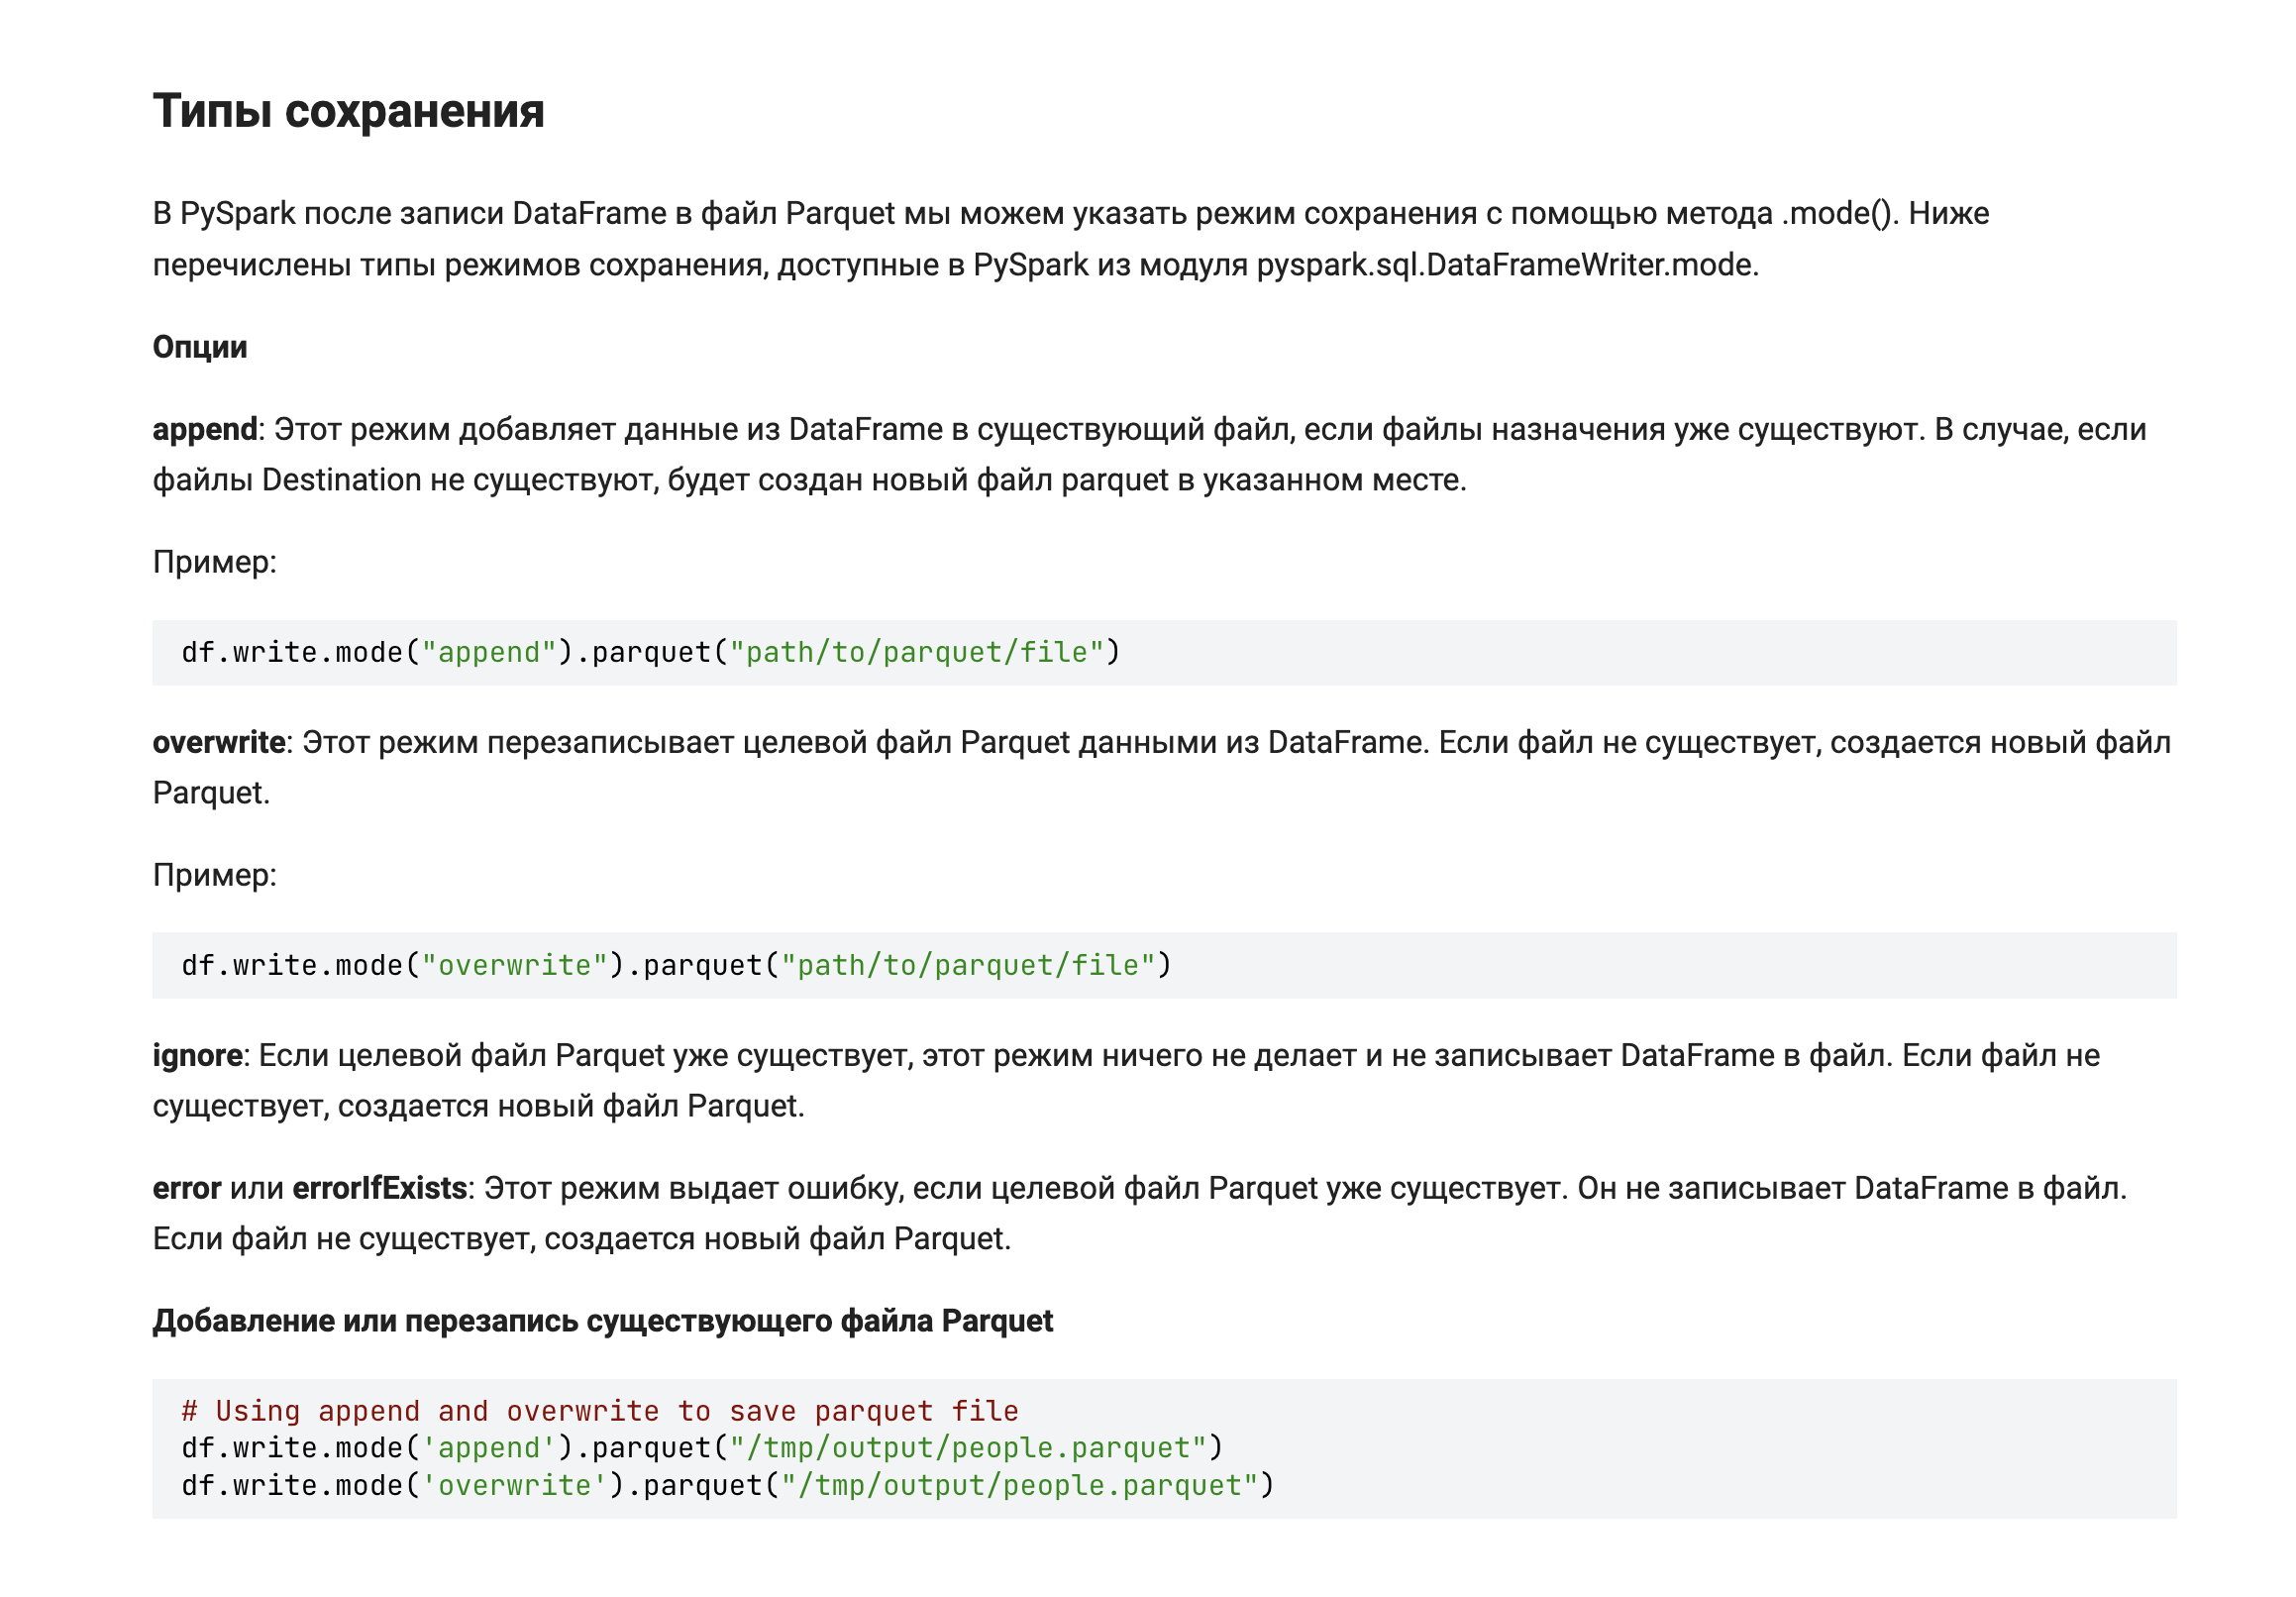

---

**Паркетные работы**

***Выполнение SQL-запросов***

Pyspark SQL позволяет создавать временные представления в паркетных файлах для выполнения sql-запросов. Эти представления доступны до тех пор, пока существует ваша программа.

In [11]:
# Using spark.sql
parDF.createOrReplaceTempView("ParquetTable")
parkSQL = spark.sql("select * from ParquetTable where salary >= 4000 ")

---
**Создание таблицы поверх файла Parquet**

Теперь давайте рассмотрим выполнение SQL-запросов в паркетном файле. Чтобы выполнить sql-запросы, создайте временное представление или таблицу непосредственно в паркетном файле вместо того, чтобы создавать их из DataFrame.

In [ ]:
# Здесь мы создали временное представление PERSON из файла «people.parquet». 
# Это дает следующие результаты.

spark.sql("CREATE TEMPORARY VIEW PERSON USING parquet OPTIONS (path \"people.parquet\")")
spark.sql("SELECT * FROM PERSON").show()

+---------+----------+--------+-----+------+------+
|firstname|middlename|lastname|  dob|gender|salary|
+---------+----------+--------+-----+------+------+
|  Robert |          |Williams|42114|     M|  4000|
|   Maria |      Anne|   Jones|39192|     F|  4000|
| Michael |      Rose|        |40288|     M|  4000|
|   James |          |   Smith|36636|     M|  3000|
|      Jen|      Mary|   Brown|     |     F|    -1|
+---------+----------+--------+-----+------+------+



---
**Разбиение данных файла Parquet**

Когда мы выполняем определенный запрос к таблице PERSON, он сканирует все строки и возвращает результаты. Это похоже на традиционное выполнение запроса к базе данных. В PySpark мы можем оптимизировать выполнение запроса, выполнив разбиение данных на разделы с помощью метода pyspark partitionBy(). Ниже приведен пример использования метода partitionBy().

In [ ]:
df.write.partitionBy("gender","salary").mode("overwrite").parquet("people2.parquet")

# Когда вы проверяете файл people2.parquet, внутри него есть два раздела «gender» и «salary».

--- 
**Получение данных из разбитого на разделы файла Parquet**

Приведенный ниже пример показывает,  как считывать информацию из разбитого на разделы Parquet.

In [18]:
parDF2=spark.read.parquet("people2.parquet/gender=M")
parDF2.show(truncate=False)

+---------+----------+--------+-----+------+
|firstname|middlename|lastname|dob  |salary|
+---------+----------+--------+-----+------+
|Robert   |          |Williams|42114|4000  |
|Michael  |Rose      |        |40288|4000  |
|James    |          |Smith   |36636|3000  |
+---------+----------+--------+-----+------+



---
**Создание таблицы в разделенном файле Parquet**

Здесь я создаю таблицу в паркетном файле с разделами и выполняю запрос, который выполняется быстрее, чем на таблице без разделов, что повышает производительность.

In [19]:
# Create a temporary view on partitioned Parquet file
spark.sql("CREATE TEMPORARY VIEW PERSON2 USING parquet OPTIONS (path \"people2.parquet/gender=F\")")
spark.sql("SELECT * FROM PERSON2" ).show()

+---------+----------+--------+-----+------+
|firstname|middlename|lastname|  dob|salary|
+---------+----------+--------+-----+------+
|   Maria |      Anne|   Jones|39192|  4000|
|      Jen|      Mary|   Brown|     |    -1|
+---------+----------+--------+-----+------+



In [20]:
spark.stop()